# Predict Wine Variety from text: Embeddings + PyTorch

* YouTube video of the code: [https://youtu.be/CDHLb_2_gMs]
* VitoshAcademy article: [https://www.vitoshacademy.com/predict-wine-variety-from-text-embeddings-pytorch/]
* Kaggle: [https://www.kaggle.com/datasets/zynicide/wine-reviews/data]
* WineEnthusias: [www.wineenthusiast.com]

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(67)
np.random.seed(67)

In [3]:
df = pd.read_csv("data/winemag-data-130k-v2.csv", index_col=0)

In [4]:
df

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Anna Lee C. Iijima,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


In [5]:
df["variety"].value_counts().head(12)

variety
Pinot Noir                  13272
Chardonnay                  11753
Cabernet Sauvignon           9472
Red Blend                    8946
Bordeaux-style Red Blend     6915
Riesling                     5189
Sauvignon Blanc              4967
Syrah                        4142
Rosé                         3564
Merlot                       3102
Nebbiolo                     2804
Zinfandel                    2714
Name: count, dtype: int64

In [6]:
bg = df[df["country"] == "Bulgaria"]

In [7]:
bg

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
6970,Bulgaria,This pale-pink rosé is comprised of 70% Pinot ...,Veni Vidi Vici,86,9.0,Thracian Valley,NaN,NaN,Jeff Jenssen,@worldwineguys,Vini 2016 Veni Vidi Vici Rosé (Thracian Valley),Rosé,Vini
7933,Bulgaria,"Dark garnet to the eye, this wine has aromas o...",NaN,90,11.0,Thracian Valley,NaN,NaN,Jeff Jenssen,@worldwineguys,Bulgariana 2012 Cabernet Sauvignon (Thracian V...,Cabernet Sauvignon,Bulgariana
7938,Bulgaria,A clean nose of lemon curd sets the scene for ...,NaN,90,14.0,Danube River Plains,NaN,NaN,Jeff Jenssen,@worldwineguys,Chateau Burgozone 2014 Chardonnay (Danube Rive...,Chardonnay,Chateau Burgozone
8177,Bulgaria,"Aromas of lemon-lime, jasmine and honeysuckle ...",Le Photographe Rheinriesling,87,22.0,Thracian Valley,NaN,NaN,Jeff Jenssen,@worldwineguys,Minkov Brothers 2011 Le Photographe Rheinriesl...,Riesling,Minkov Brothers
8178,Bulgaria,This ruby-colored wine offers aromas of black ...,Le Photographe,87,22.0,Thracian Valley,NaN,NaN,Jeff Jenssen,@worldwineguys,Minkov Brothers 2014 Le Photographe Cabernet F...,Cabernet Franc,Minkov Brothers
...,...,...,...,...,...,...,...,...,...,...,...,...,...
126849,Bulgaria,Chamomile and fresh herb notes lend breeziness...,Via Diagonalis,88,17.0,Thracian Valley,NaN,NaN,Anna Lee C. Iijima,NaN,Castra Rubra 2011 Via Diagonalis White (Thraci...,White Blend,Castra Rubra
127621,Bulgaria,This garnet-colored Bulgarian Cabernet Sauvign...,Reserve,90,11.0,Thracian Valley,NaN,NaN,Jeff Jenssen,@worldwineguys,Domaine Boyar 2013 Reserve Cabernet Sauvignon ...,Cabernet Sauvignon,Domaine Boyar
127918,Bulgaria,This Kosher red blend from Bulgaria is compris...,Via Diagonalis,89,20.0,Thracian Valley,NaN,NaN,Jeff Jenssen,@worldwineguys,Castra Rubra 2010 Via Diagonalis Red (Thracian...,Red Blend,Castra Rubra
129403,Bulgaria,"At $8, this is a great find, and has the exoti...",NaN,85,8.0,Bulgaria,NaN,NaN,Susan Kostrzewa,@suskostrzewa,Targovishte 2006 Sauvignon Blanc (Bulgaria),Sauvignon Blanc,Targovishte


In [8]:
print(df["description"].iloc[6970])

This pale-pink rosé is comprised of 70% Pinot Noir and 30% Syrah. It has aromas of lemon zest, pink grapefruit and strawberry. Red grapefruit along with strawberries and cream mark the palate. The finish is full and fruity.


In [9]:
df = df.drop_duplicates("description").dropna(subset=["variety", "description"])

In [10]:
top12 = df["variety"].value_counts().head(12).index

In [11]:
df = df[df["variety"].isin(top12)].reset_index(drop=True)

In [12]:
df.shape

(71109, 13)

In [13]:
from sentence_transformers import SentenceTransformer

In [14]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")
X = embedder.encode(df["description"].tolist(), batch_size = 64, show_progress_bar = True, normalize_embeddings = True).astype("float32")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1112 [00:00<?, ?it/s]

In [15]:
X[0][4]

np.float32(-0.0022344561)

In [16]:
X[0]

array([ 2.08346043e-02, -1.90968439e-02,  4.27478291e-02,  3.45044844e-02,
       -2.23445613e-03,  9.65140015e-02,  2.52725426e-02, -1.02332726e-01,
        7.07554072e-02, -7.14721531e-02,  3.40266004e-02, -3.40395533e-02,
       -7.84806386e-02, -5.56944944e-02,  9.19458196e-02,  3.70192416e-02,
        1.14905775e-01,  1.21935150e-02,  2.83595640e-02,  4.31268290e-03,
        3.95028666e-02,  7.37090688e-03, -7.46324137e-02, -3.40977944e-02,
       -3.41757806e-03, -2.54465323e-02,  5.73925972e-02, -4.94988682e-03,
       -2.00770795e-02, -9.47048813e-02,  7.10823685e-02,  3.06729190e-02,
        3.50201353e-02,  5.41084521e-02, -1.51926130e-01, -1.43749844e-02,
        9.15476084e-02, -1.19444099e-03,  1.16159000e-01,  9.85112488e-02,
       -1.27262492e-02,  3.53893973e-02,  7.75610432e-02, -1.85003337e-02,
       -9.39608086e-03,  1.70853157e-02, -3.49231437e-02, -2.84682047e-02,
        1.10296402e-02, -5.30284978e-02, -4.51613739e-02, -2.18974743e-02,
        2.10988056e-02, -

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [18]:
le = LabelEncoder()
y = le.fit_transform(df["variety"]).astype("int64")
n_classes = len(le.classes_)
idx = np.arange(len(df))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state = 0, stratify = y)

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

In [19]:
class GrapeNet(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        return self.net(x)

In [20]:
model = GrapeNet(X.shape[1], n_classes)

In [21]:
model

GrapeNet(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=12, bias=True)
  )
)

In [22]:
from torch.utils.data import TensorDataset, DataLoader

train_dl = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=256, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    total = 0.0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item()
    if (epoch + 1) % 2 == 0:
        print(f"epoch {epoch+1:2d}  loss {total / len(train_dl):.3f}")

epoch  2  loss 1.197
epoch  4  loss 1.005
epoch  6  loss 0.942
epoch  8  loss 0.909
epoch 10  loss 0.883
epoch 12  loss 0.860
epoch 14  loss 0.846
epoch 16  loss 0.829
epoch 18  loss 0.815
epoch 20  loss 0.805


In [23]:
model.eval()
with torch.no_grad():
    pred = model(torch.tensor(X_test)).argmax(1).numpy()

acc = (pred == y_test).mean()
print(f"Test accuracy: {acc:.3f}\n")

for i in range(3):
    print(df["description"].iloc[idx_test[i]][:150])
    print("true:", le.classes_[y_test[i]], "| predicted:", le.classes_[pred[i]])
    print()

Test accuracy: 0.722

Showcasing the southeastern Edna Valley's sandy loam soils, this begins with lush black cherry and sleek graphite aromas. On the palate, racy acidity 
true: Pinot Noir | predicted: Pinot Noir

Fruity aromas of dark berry and scorched soil lead the nose on this informal red. The simple easygoing palate offers morello cherry and a hint of drie
true: Red Blend | predicted: Red Blend

While the nose is exuberant and tropical with swirls of mango and pineapple, the palate of this dry Riesling is surprisingly dainty. Crisp pear and ta
true: Riesling | predicted: Riesling



In [24]:
from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=1000).fit(X_train, y_train)

print(f"Neural network:      {acc:.3f}")
print(f"Logistic regression: {baseline.score(X_test, y_test):.3f}")

Neural network:      0.722
Logistic regression: 0.706


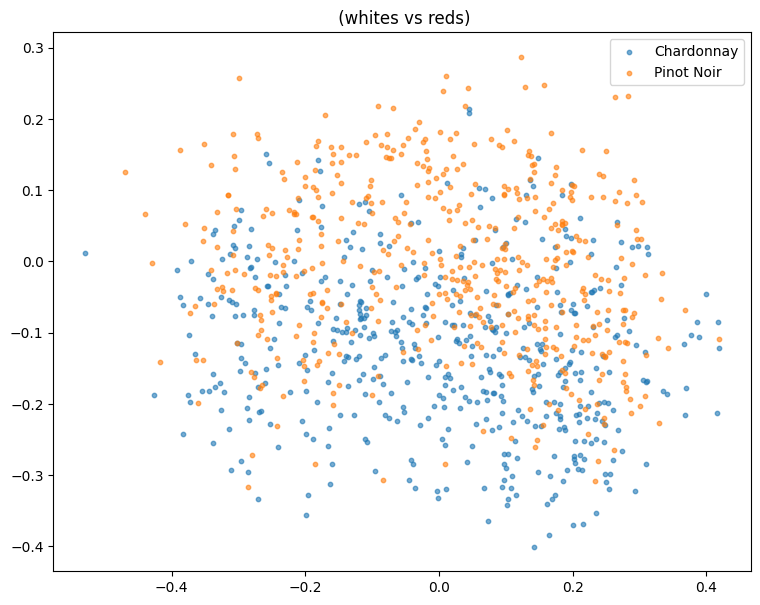

In [25]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=0).fit_transform(X)

show = ["Chardonnay","Pinot Noir"]

plt.figure(figsize=(9, 7))
for grape in show:
    pts = coords[df["variety"].values == grape]
    sub = np.random.choice(len(pts), min(500, len(pts)), replace=False)
    plt.scatter(pts[sub, 0], pts[sub, 1], s=10, alpha=0.6, label=grape)

plt.legend()
plt.title(" (whites vs reds)")
plt.show()

In [26]:
def predict_grape(text):
    vec = embedder.encode([text], normalize_embeddings=True).astype("float32")
    with torch.no_grad():
        probs = torch.softmax(model(torch.tensor(vec)), 1)[0]
    top = probs.topk(12)
    for p, i in zip(top.values, top.indices):
        print(f"  {le.classes_[i]:24s} {p.item()*100:.1f}%")

In [27]:
predict_grape("70% Pinot Noir and 30% Syrah. It has aromas of lemon zest, pink grapefruit and strawberry. ")

  Rosé                     61.0%
  Syrah                    12.9%
  Red Blend                11.9%
  Sauvignon Blanc          8.9%
  Pinot Noir               2.0%
  Chardonnay               1.7%
  Riesling                 1.2%
  Zinfandel                0.2%
  Merlot                   0.1%
  Cabernet Sauvignon       0.1%
  Bordeaux-style Red Blend 0.0%
  Nebbiolo                 0.0%
